# **Playing Around cries**

**Import packages and data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("mergeICU_db.csv")

In [ ]:
df.head(5)

,patientunitstayid,gender,age,ethnicity,hospitalid,unittype,admissionheight,admissionweight,dischargeweight,unitadmitsource,...,ventday1,nettotal,sao2_mean,sao2_min,heartrate_mean,heartrate_max,heartrate_std,respiration_mean,respiration_max,bad_outcome
0,141764,Female,87,Caucasian,59,Med-Surg ICU,157.5,NaN,NaN,ICU to SDU,...,NaN,-500.00,NaN,NaN,106.652174,138.0,11.339450,NaN,NaN,0
1,141765,Female,87,Caucasian,59,Med-Surg ICU,157.5,46.5,45.0,Emergency Department,...,0.0,3025.00,96.608696,95.0,83.190972,116.0,8.031839,24.782609,39.0,0
2,143870,Male,76,Caucasian,68,SICU,167.0,77.5,79.4,Operating Room,...,0.0,4201.00,96.284810,80.0,45.449367,55.0,2.594820,67.031646,86.0,0
3,144815,Female,34,Caucasian,56,Med-Surg ICU,172.7,60.3,60.7,Emergency Department,...,0.0,4500.00,98.630682,96.0,83.800000,118.0,10.483560,16.927273,42.0,0
4,145427,Male,61,Caucasian,68,SICU,177.8,91.7,93.1,Operating Room,...,0.0,11283.16,95.761905,89.0,65.457983,85.0,7.862500,16.349206,41.0,0


**Initial Look**

In [ ]:
df.shape

#2520 rows and 55 columns

(2520, 55)

In [ ]:
df.columns

Index(['patientunitstayid', 'gender', 'age', 'ethnicity', 'hospitalid',
       'unittype', 'admissionheight', 'admissionweight', 'dischargeweight',
       'unitadmitsource', 'hospitaladmitsource', 'numbedscategory',
       'teachingstatus', 'region', 'acutephysiologyscore', 'apachescore',
       'intubated', 'dialysis', 'temperature', 'respiratoryrate', 'heartrate',
       'meanbp', 'urine', 'creatinine', 'bun', 'sodium', 'hematocrit',
       'albumin', 'glucose', 'bilirubin', 'pao2', 'pco2', 'fio2', 'ph',
       'admitsource', 'aids', 'hepaticfailure', 'lymphoma', 'metastaticcancer',
       'leukemia', 'immunosuppression', 'cirrhosis', 'diabetes',
       'electivesurgery', 'activetx', 'ventday1', 'nettotal', 'sao2_mean',
       'sao2_min', 'heartrate_mean', 'heartrate_max', 'heartrate_std',
       'respiration_mean', 'respiration_max', 'bad_outcome'],
      dtype='object')

In [ ]:
df.dtypes

,0
patientunitstayid,int64
gender,object
age,object
ethnicity,object
hospitalid,int64
unittype,object
admissionheight,float64
admissionweight,float64
dischargeweight,float64
unitadmitsource,object


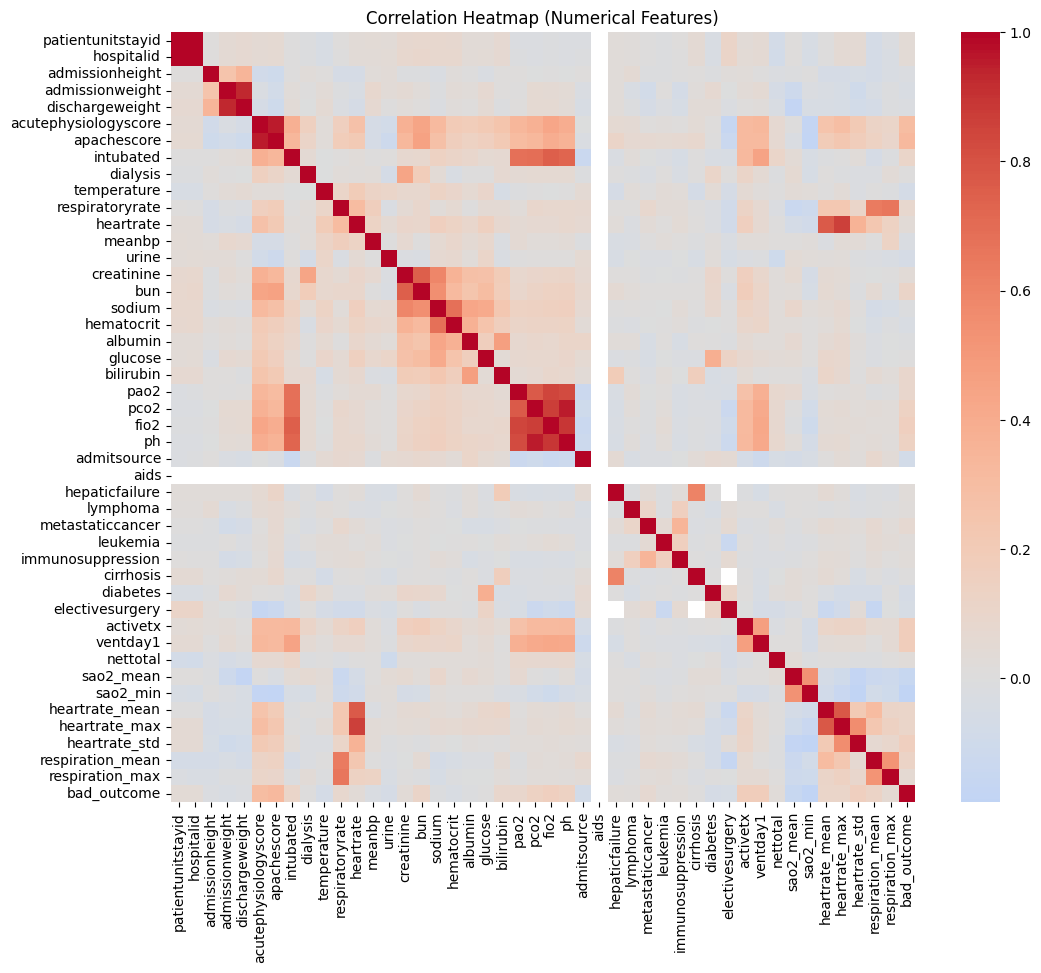

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()



In [ ]:
# Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Convert matrix to a list of pairs
corr_list = corr_matrix.unstack().reset_index()
corr_list.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Remove self-correlations (where correlation = 1)
corr_list = corr_list[corr_list['Correlation'] < 1]

# Optional: sort by absolute correlation descending
corr_list['abs_correlation'] = corr_list['Correlation'].abs()
corr_list = corr_list.sort_values(by='abs_correlation', ascending=False)

# Drop the helper column if desired
corr_list = corr_list.drop(columns='abs_correlation')

# Display the entire list
print(corr_list)



                 Feature_1             Feature_2  Correlation
46              hospitalid     patientunitstayid     0.993541
1        patientunitstayid            hospitalid     0.993541
281            apachescore  acutephysiologyscore     0.949360
236   acutephysiologyscore           apachescore     0.949360
1126                    ph                  pco2     0.949168
...                    ...                   ...          ...
581                 meanbp      metastaticcancer     0.000183
1010                  pao2       respiration_max     0.000040
2045       respiration_max                  pao2     0.000040
1515             cirrhosis      respiration_mean     0.000018
2010      respiration_mean             cirrhosis     0.000018

[1976 rows x 3 columns]


In [ ]:
df["bad_outcome"].value_counts()

# 293 patients died or were readmitted

,count
bad_outcome,
0,2227
1,293


/tmp/ipython-input-945680927.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="bad_outcome", data=df, palette="Blues")


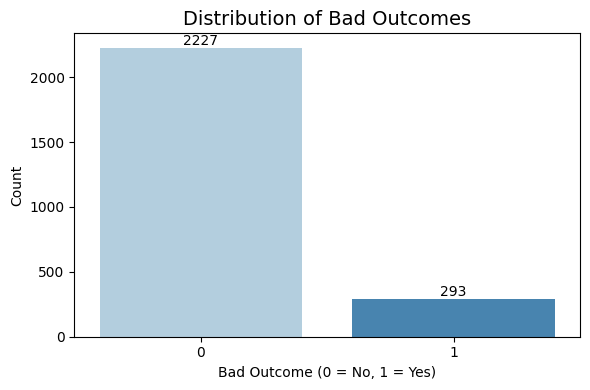

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
ax = sns.countplot(x="bad_outcome", data=df, palette="Blues")

# Add count labels on top of bars
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.title("Distribution of Bad Outcomes", fontsize=14)
plt.xlabel("Bad Outcome (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
df[df['bad_outcome'] == 1]

,patientunitstayid,gender,age,ethnicity,hospitalid,unittype,admissionheight,admissionweight,dischargeweight,unitadmitsource,...,ventday1,nettotal,sao2_mean,sao2_min,heartrate_mean,heartrate_max,heartrate_std,respiration_mean,respiration_max,bad_outcome
13,151179,Female,59,Caucasian,66,Med-Surg ICU,149.9,NaN,73.0,Emergency Department,...,0.0,21286.61,96.024476,92.0,98.978873,171.0,13.052473,27.323843,48.0,1
33,162841,Female,84,Caucasian,59,Med-Surg ICU,160.0,78.80,81.6,Floor,...,0.0,43838.35,97.760000,92.0,70.276596,94.0,12.491196,20.866667,25.0,1
42,165840,Male,81,Caucasian,61,Med-Surg ICU,167.0,92.40,92.4,Emergency Department,...,1.0,0.00,94.800000,89.0,83.000000,86.0,1.885618,27.000000,29.0,1
43,165841,Male,81,Caucasian,61,Med-Surg ICU,167.0,NaN,NaN,ICU to SDU,...,NaN,NaN,98.750000,98.0,78.600000,80.0,0.680557,NaN,NaN,1
77,179028,Male,87,Caucasian,68,SICU,167.6,54.40,54.0,Floor,...,1.0,2126.00,97.849265,91.0,77.416667,106.0,8.811222,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2500,3344942,Female,63,Caucasian,459,Med-Surg ICU,165.1,129.80,136.0,Step-Down Unit (SDU),...,0.0,21199.31,96.284211,84.0,102.631579,122.0,11.687588,21.950877,43.0,1
2502,3344944,Female,63,Caucasian,459,Med-Surg ICU,165.1,129.80,122.5,Floor,...,0.0,-4081.05,97.455959,93.0,109.489899,126.0,7.801952,22.919192,44.0,1
2503,3344945,Female,63,Caucasian,459,Med-Surg ICU,165.1,129.80,140.9,Step-Down Unit (SDU),...,1.0,3863.67,99.925110,98.0,70.013216,79.0,3.716122,17.453744,38.0,1
2510,3348293,Female,87,Caucasian,459,Med-Surg ICU,160.0,49.44,56.1,Floor,...,0.0,-19604.00,96.010453,91.0,99.724739,125.0,8.615577,24.170732,37.0,1


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
electivesurgery,2178
dischargeweight,1284
acutephysiologyscore,682
apachescore,682
hospitaladmitsource,594
respiration_max,367
respiration_mean,367
numbedscategory,346
nettotal,335
meanbp,315


## **Super Rough Baseline - Logistic Regression**

In [ ]:
X = df.drop(columns=['bad_outcome'])
y = df['bad_outcome']


In [ ]:
# Add missing indicators
for col in X.columns:
    if X[col].isnull().any():
        X[col + '_missing'] = X[col].isnull().astype(int)

# Separate numeric and categorical
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

# Fill numeric with median
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical with mode
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

              precision    recall  f1-score   support

           0     0.9511    0.7438    0.8348       445
           1     0.2692    0.7119    0.3907        59

    accuracy                         0.7401       504
   macro avg     0.6102    0.7278    0.6128       504
weighted avg     0.8713    0.7401    0.7828       504

ROC-AUC: 0.7927632831841555


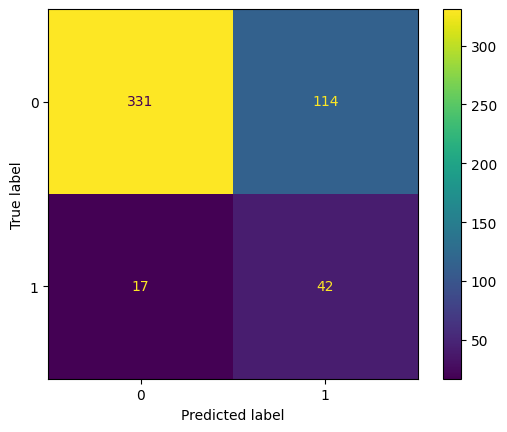

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


              precision    recall  f1-score   support

           0     0.9511    0.7438    0.8348       445
           1     0.2692    0.7119    0.3907        59

    accuracy                         0.7401       504
   macro avg     0.6102    0.7278    0.6128       504
weighted avg     0.8713    0.7401    0.7828       504

ROC-AUC: 0.7927632831841555


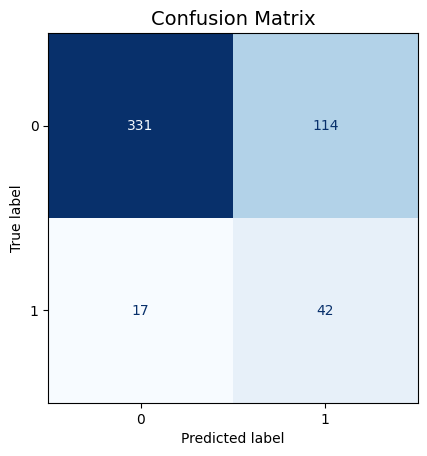

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions and probabilities
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Print metrics
print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Blue confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',
    colorbar=False
)
plt.title("Confusion Matrix", fontsize=14)
plt.show()


In [ ]:
importance = np.abs(model.coef_[0])
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feature_importance.head(15)


,feature,importance
6,apachescore,0.016726
39,sao2_min,0.016297
15,bun,0.011878
23,fio2,0.011502
5,acutephysiologyscore,0.009884
40,heartrate_mean,0.009470
11,heartrate,0.008365
9,temperature,0.007368
22,pco2,0.007121
10,respiratoryrate,0.007003


## **Super Rough Baseline - Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

              precision    recall  f1-score   support

           0     0.8847    1.0000    0.9388       445
           1     1.0000    0.0169    0.0333        59

    accuracy                         0.8849       504
   macro avg     0.9423    0.5085    0.4861       504
weighted avg     0.8982    0.8849    0.8328       504

ROC-AUC: 0.8529042087221482


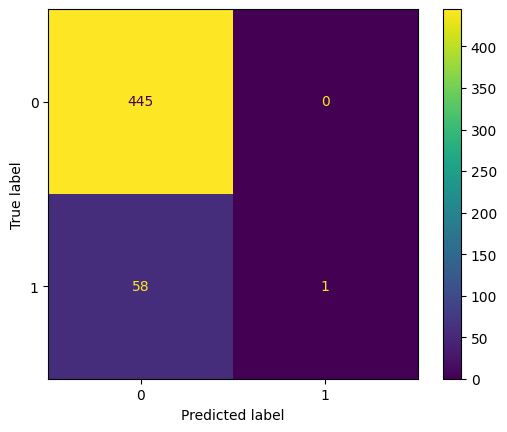

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()
